In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler


In [2]:
# Load the dataset
file_path = "/content/transformed_dataset.csv"
df = pd.read_csv(file_path)

# Display basic info about the dataset
print("Dataset Shape:", df.shape)
print("\nDataset Overview:")
display(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)


Dataset Shape: (7304, 7)

Dataset Overview:


,Date,Temperature,Precipitation,Humidity,Plant Family,Location,Place
0,20190101,24.80,0.12,80.00,Lamiaceae (Basil),Colombo,Indoor
1,20190102,24.39,0.02,79.50,Lamiaceae (Basil),Colombo,Indoor
2,20190103,24.17,0.01,78.50,Lamiaceae (Basil),Colombo,Indoor
3,20190104,24.04,0.00,77.62,Lamiaceae (Basil),Colombo,Indoor
4,20190105,24.87,0.03,81.50,Alliaceae (Green Onions),Colombo,Indoor



Missing Values:
Date                0
Temperature         0
Precipitation       0
Humidity            0
Plant Family     2661
Location            0
Place               0
dtype: int64

Data Types:
Date               int64
Temperature      float64
Precipitation    float64
Humidity         float64
Plant Family      object
Location          object
Place             object
dtype: object


In [3]:
# Replace common placeholders for missing values (modify as needed)
df.replace(["?", "unknown", "N/A", "NaN"], np.nan, inplace=True)

# Fill missing numerical values with the median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values with the most frequent value
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

# Verify no missing values remain
print("\nMissing Values After Handling:")
print(df.isnull().sum())

# Save the cleaned dataset
df.to_csv("/content/cleaned_dataset.csv", index=False)



Missing Values After Handling:
Date             0
Temperature      0
Precipitation    0
Humidity         0
Plant Family     0
Location         0
Place            0
dtype: int64


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# Load the cleaned dataset
file_path = "/content/cleaned_dataset.csv"
df = pd.read_csv(file_path)

# Store the target variable separately
target = df["Plant Family"]

# Identify categorical features (excluding target)
cat_cols = [col for col in df.select_dtypes(include=["object"]).columns if col != "Plant Family"]
num_cols = df.select_dtypes(include=["int64", "float64"]).columns  # Numerical columns

# One-Hot Encoding for categorical variables
encoder = OneHotEncoder(sparse_output=False, drop="first")  # Drop first to avoid dummy variable trap
encoded_data = encoder.fit_transform(df[cat_cols])

# Convert encoded array to DataFrame with meaningful column names
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_cols))

# Drop original categorical columns and add encoded features
df = df.drop(columns=cat_cols).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)

# Normalize numerical features
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Reattach the target variable
df["Plant Family"] = target

# Save the preprocessed dataset
df.to_csv("/content/preprocessed_dataset.csv", index=False)

# Display dataset information
print("Preprocessing complete. Dataset saved as 'preprocessed_dataset.csv'.")
display(df.head())


Preprocessing complete. Dataset saved as 'preprocessed_dataset.csv'.


,Date,Temperature,Precipitation,Humidity,Plant Family,Location_Kandy,Place_Indoor
0,0.000000,0.457467,0.001226,0.634697,Lamiaceae (Basil),0.0,1.0
1,0.000024,0.418715,0.000204,0.623519,Lamiaceae (Basil),0.0,1.0
2,0.000049,0.397921,0.000102,0.601163,Lamiaceae (Basil),0.0,1.0
3,0.000073,0.385633,0.000000,0.581489,Lamiaceae (Basil),0.0,1.0
4,0.000097,0.464083,0.000306,0.668232,Alliaceae (Green Onions),0.0,1.0


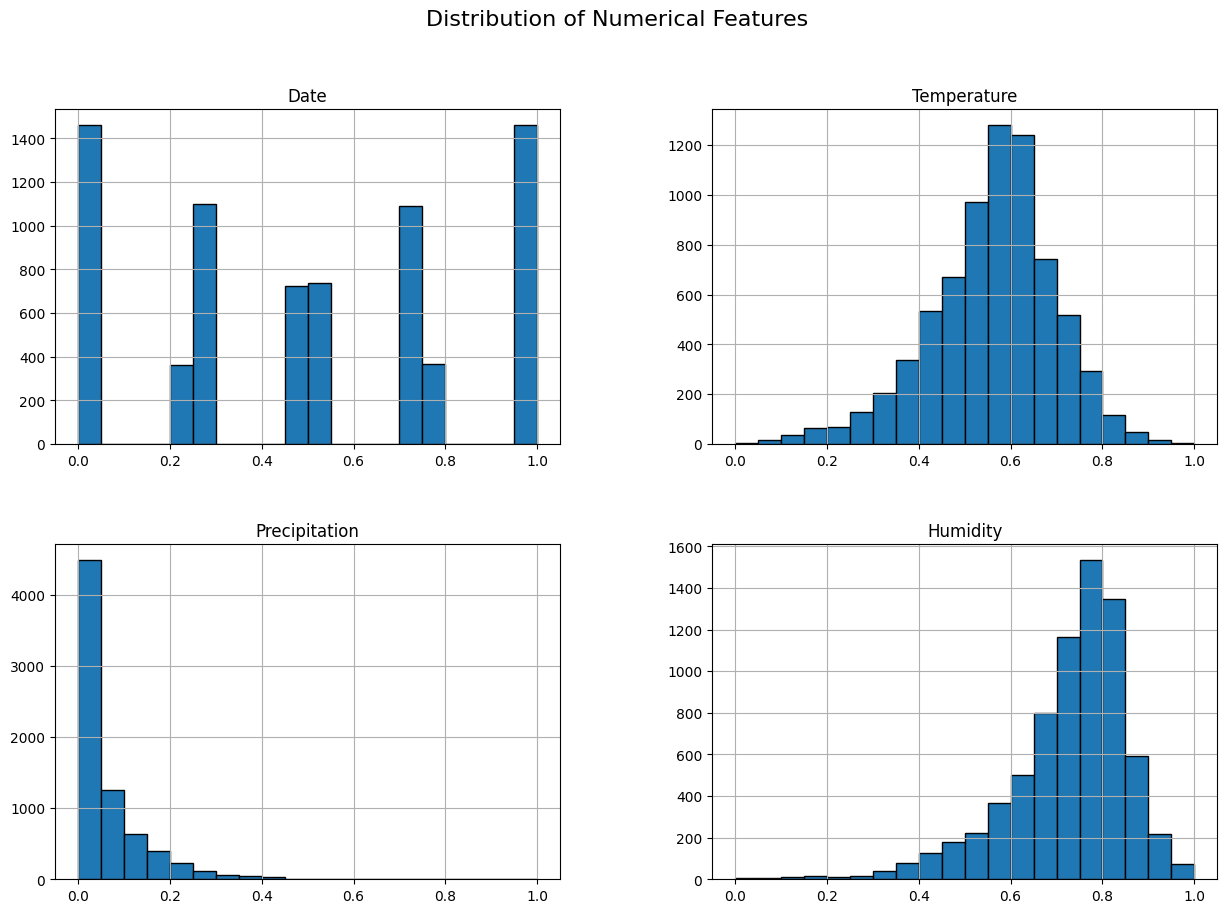

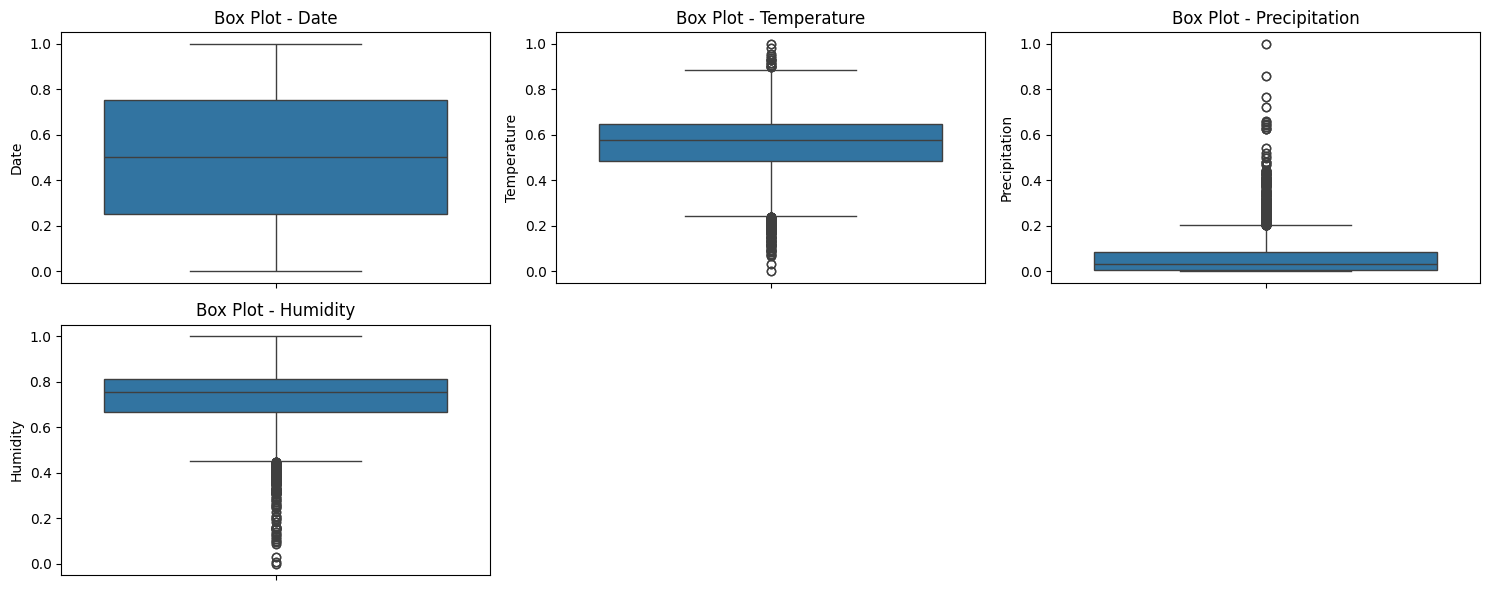

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical features
df[num_cols].hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

# Box plots to check for outliers
plt.figure(figsize=(15, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, (len(num_cols) // 2) + 1, i)
    sns.boxplot(y=df[col])
    plt.title(f"Box Plot - {col}")
plt.tight_layout()
plt.show()

<ipython-input-6-68cfca2af0c2>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")
<ipython-input-6-68cfca2af0c2>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")


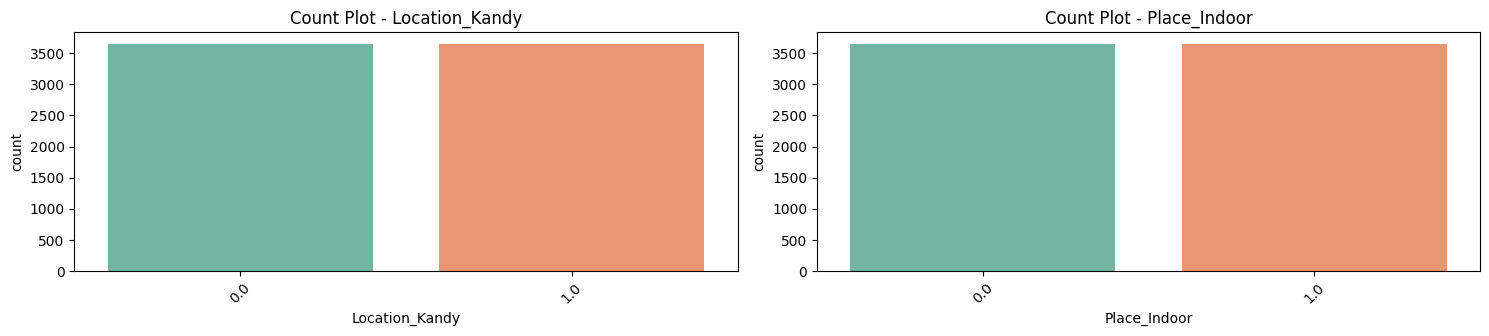

In [6]:
# Count plots for categorical features
plt.figure(figsize=(15, 6))
# Iterate through the encoded columns from encoded_df instead of cat_features
for i, col in enumerate(encoded_df.columns, 1):
    plt.subplot(2, (len(encoded_df.columns) // 2) + 1, i)
    sns.countplot(x=df[col], palette="Set2")
    plt.xticks(rotation=45)
    plt.title(f"Count Plot - {col}")
plt.tight_layout()
plt.show()

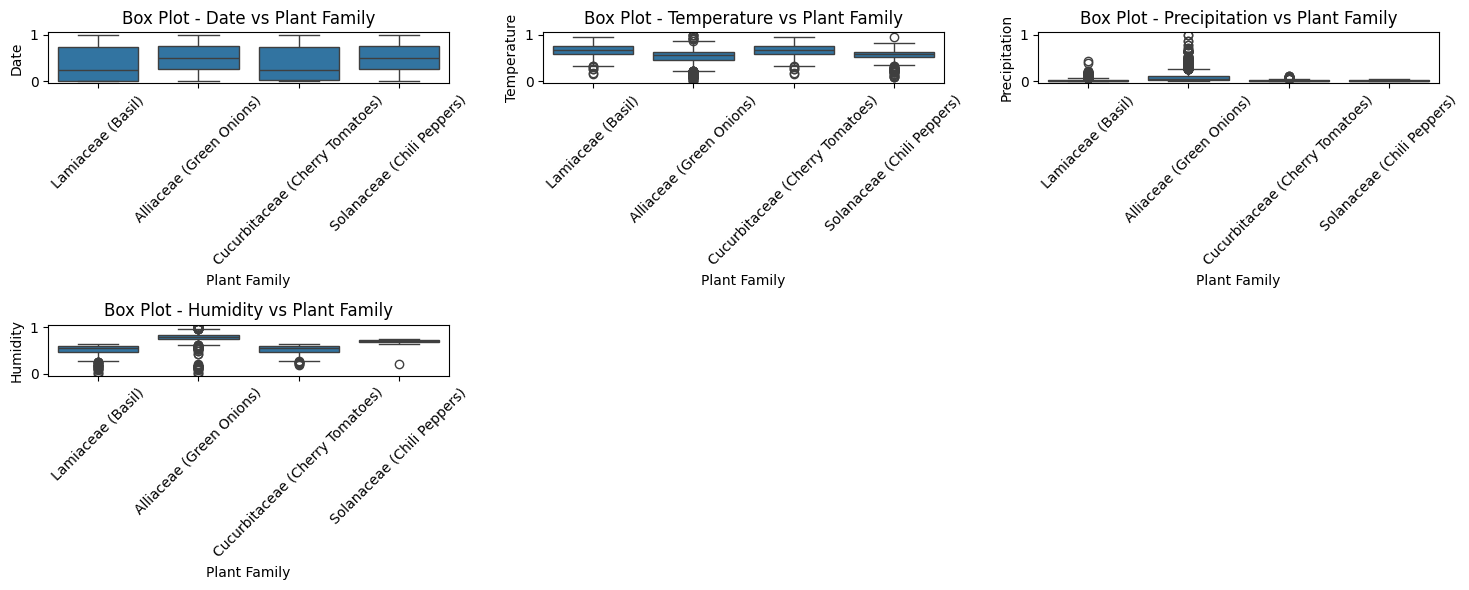

<ipython-input-7-a1b2d9283c0b>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=target.index, palette="Set2")
<ipython-input-7-a1b2d9283c0b>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=target.index, palette="Set2")


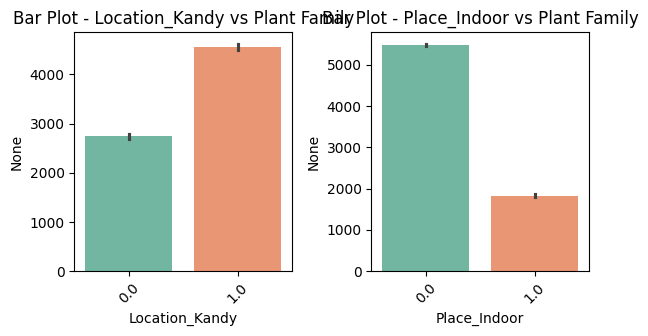

In [7]:

# Boxplots to visualize numerical feature distributions by target variable
plt.figure(figsize=(15, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, (len(num_cols) // 2) + 1, i)
    sns.boxplot(x=target, y=df[col])
    plt.xticks(rotation=45)
    plt.title(f"Box Plot - {col} vs Plant Family")
plt.tight_layout()
plt.show()

# Count plots to visualize categorical feature impact on the target variable
plt.figure(figsize=(15, 6))
for i, col in enumerate(encoded_df.columns[:10], 1):  # Limit to first 10 for clarity
    plt.subplot(2, 5, i)
    sns.barplot(x=df[col], y=target.index, palette="Set2")
    plt.xticks(rotation=45)
    plt.title(f"Bar Plot - {col} vs Plant Family")
plt.tight_layout()
plt.show()


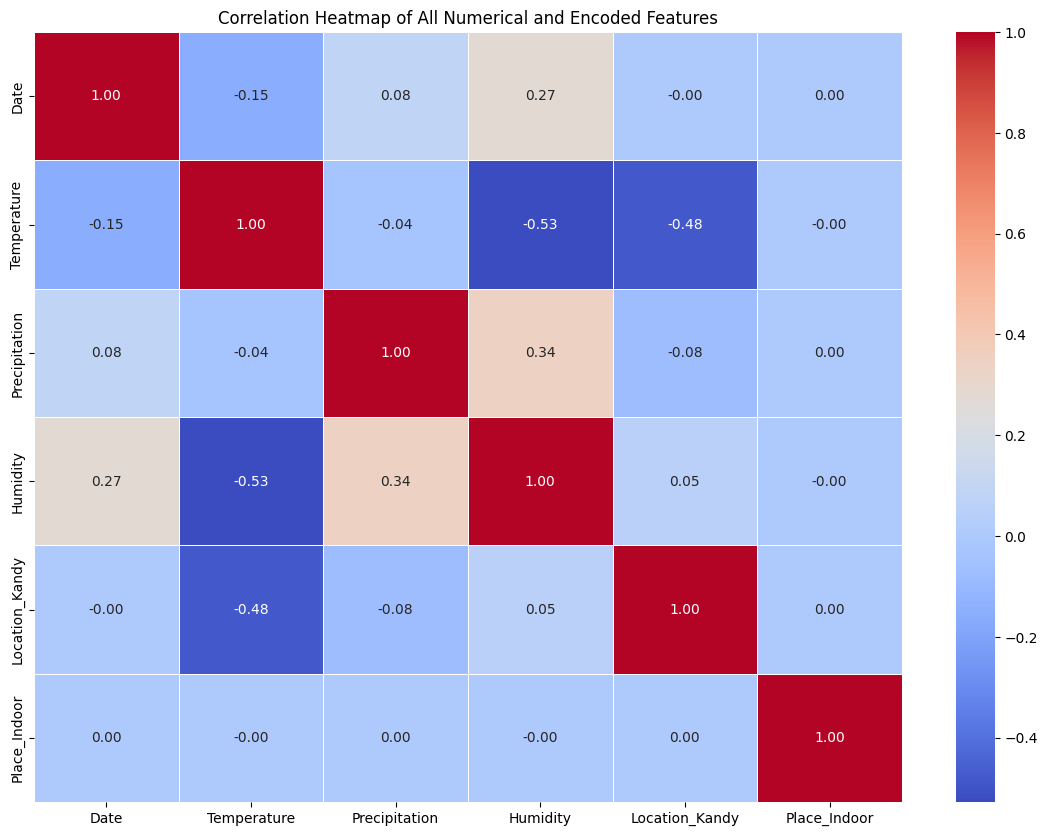

In [8]:
# Include one-hot encoded categorical features in correlation analysis
encoded_feature_cols = encoded_df.columns.tolist()  # Get names of encoded categorical features
all_numeric_cols = num_cols.tolist() + encoded_feature_cols  # Combine numerical and encoded categorical features

# Correlation Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df[all_numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of All Numerical and Encoded Features")
plt.show()


<ipython-input-9-3414e8acef62>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Plant Family"], palette="coolwarm")


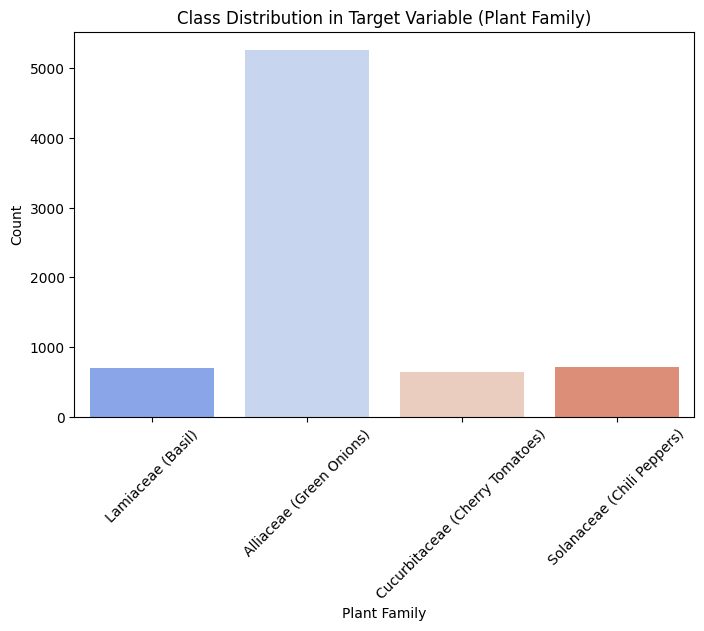

Class Distribution Before Balancing: Counter({'Alliaceae (Green Onions)': 5255, 'Solanaceae (Chili Peppers)': 712, 'Lamiaceae (Basil)': 695, 'Cucurbitaceae (Cherry Tomatoes)': 642})


In [9]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# Count the occurrences of each class in "Plant Family"
plt.figure(figsize=(8, 5))
sns.countplot(x=df["Plant Family"], palette="coolwarm")
plt.title("Class Distribution in Target Variable (Plant Family)")
plt.xlabel("Plant Family")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Print class distribution
class_counts = Counter(df["Plant Family"])
print("Class Distribution Before Balancing:", class_counts)


SMOTE applied. Dataset balanced successfully.


<ipython-input-10-884ac15978c1>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_balanced["Plant Family"], palette="coolwarm")


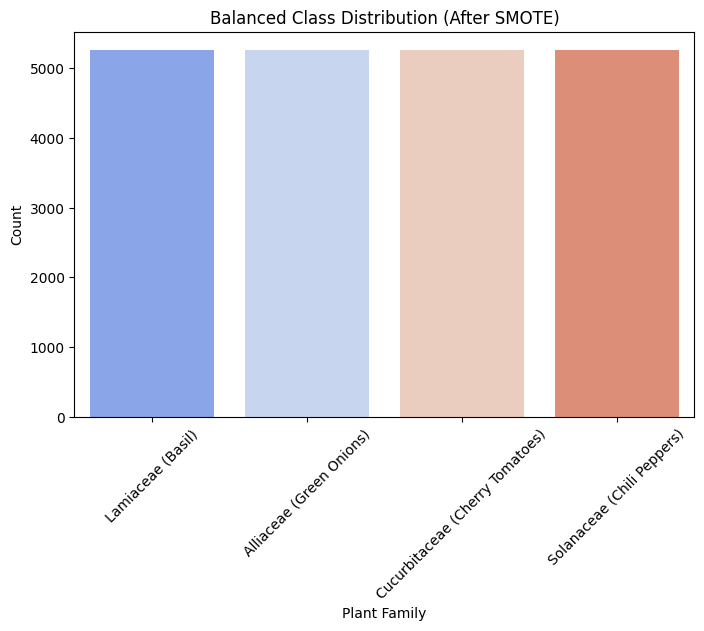

In [10]:
# Separate features (X) and target (y)
X = df.drop(columns=["Plant Family"])  # Features
y = df["Plant Family"]  # Target

# Apply SMOTE only if class imbalance is detected
imbalance_ratio = min(class_counts.values()) / max(class_counts.values())

if imbalance_ratio < 0.8:  # Only apply SMOTE if there's a significant imbalance
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    # Create a new balanced dataset
    df_balanced = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.DataFrame(y_resampled, columns=["Plant Family"])], axis=1)

    # Save the balanced dataset
    df_balanced.to_csv("/content/balanced_dataset.csv", index=False)

    print("SMOTE applied. Dataset balanced successfully.")
else:
    df_balanced = df  # Keep original dataset if already balanced
    print("No balancing needed. Dataset already balanced.")

# Plot the new balanced target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=df_balanced["Plant Family"], palette="coolwarm")
plt.title("Balanced Class Distribution (After SMOTE)")
plt.xlabel("Plant Family")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

# Load the balanced dataset
file_path = "/content/balanced_dataset.csv"
df_balanced = pd.read_csv(file_path)

# Separate features and target variable
X = df_balanced.drop(columns=["Plant Family"])  # Features
y = df_balanced["Plant Family"]  # Target

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)


Training Set Shape: (16816, 6)
Test Set Shape: (4204, 6)


In [12]:
# Initialize Random Forest with default parameters
rf = RandomForestClassifier(random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Predict on train and test sets
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Evaluate the model
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Baseline Random Forest Accuracy:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Check for overfitting
if train_acc - test_acc > 0.05:
    print("Warning: Possible overfitting detected!")


Baseline Random Forest Accuracy:
Training Accuracy: 1.0000
Test Accuracy: 0.9993


In [13]:
# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],  # Number of trees
    "max_depth": [10, 20, 30],  # Tree depth
    "min_samples_split": [2, 5, 10],  # Min samples to split a node
    "min_samples_leaf": [1, 2, 4]  # Min samples per leaf
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Get best parameters and retrain model
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the optimized model
rf_best = RandomForestClassifier(**best_params, random_state=42)
rf_best.fit(X_train, y_train)

# Predict again with the optimized model
y_train_pred_best = rf_best.predict(X_train)
y_test_pred_best = rf_best.predict(X_test)

# Evaluate the optimized model
train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print("\nOptimized Random Forest Accuracy:")
print(f"Training Accuracy: {train_acc_best:.4f}")
print(f"Test Accuracy: {test_acc_best:.4f}")

# Compare overfitting again
if train_acc_best - test_acc_best > 0.05:
    print("Warning: Optimized model still shows signs of overfitting!")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}

Optimized Random Forest Accuracy:
Training Accuracy: 0.9995
Test Accuracy: 0.9990



Classification Report (Test Set):
                                  precision    recall  f1-score   support

       Alliaceae (Green Onions)       1.00      1.00      1.00      1051
Cucurbitaceae (Cherry Tomatoes)       1.00      1.00      1.00      1051
              Lamiaceae (Basil)       1.00      1.00      1.00      1051
     Solanaceae (Chili Peppers)       1.00      1.00      1.00      1051

                       accuracy                           1.00      4204
                      macro avg       1.00      1.00      1.00      4204
                   weighted avg       1.00      1.00      1.00      4204



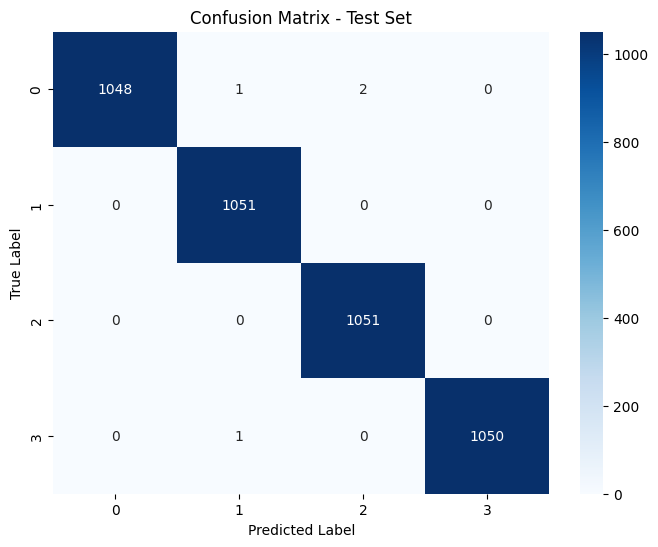

<ipython-input-14-b3516dc6ce37>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Train Accuracy", "Test Accuracy"], y=[train_acc_best, test_acc_best], palette="coolwarm")


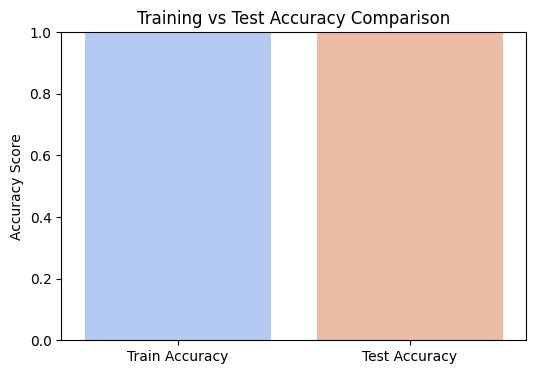

In [14]:
# Classification report
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_test_pred_best))

# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_test_pred_best), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Compare Train vs Test Accuracy
plt.figure(figsize=(6, 4))
sns.barplot(x=["Train Accuracy", "Test Accuracy"], y=[train_acc_best, test_acc_best], palette="coolwarm")
plt.ylim(0, 1)
plt.title("Training vs Test Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.show()


<ipython-input-15-749040014e1c>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importances_df, palette="viridis")


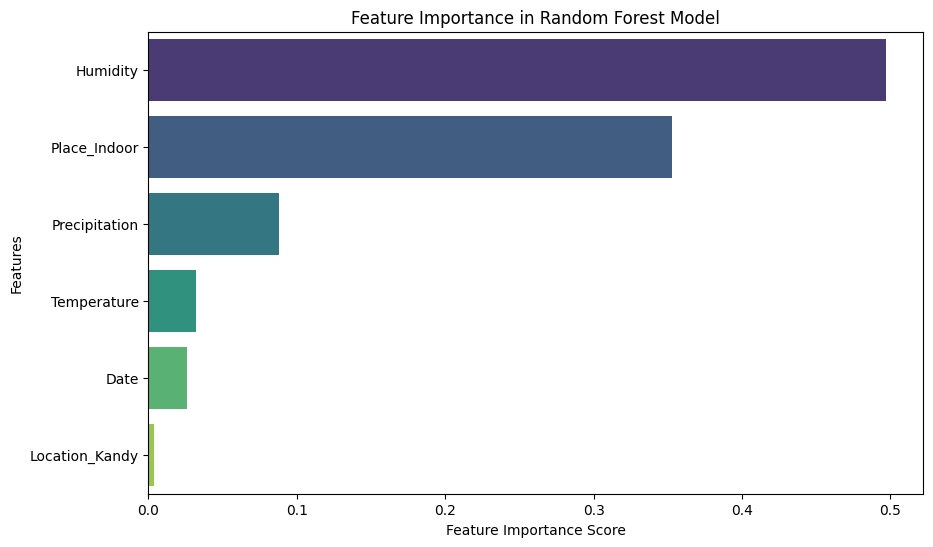

In [15]:
# Get feature importances from the best model
feature_importances = rf_best.feature_importances_

# Create a DataFrame for better visualization
importances_df = pd.DataFrame({"Feature": X.columns, "Importance": feature_importances})
importances_df = importances_df.sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importances_df, palette="viridis")
plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.show()